In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import plotly.express as px
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../Dataset/DataBase.csv')
print(len(df), 'rows')
df

2304 rows


,actuator,sensor,time
0,255,1008,2.160
1,255,821,2.175
2,255,699,2.190
3,255,495,2.250
4,255,472,2.265
...,...,...,...
2299,122,509,99.855
2300,122,456,99.900
2301,122,481,99.945
2302,122,467,99.990


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   actuator  2304 non-null   int64  
 1   sensor    2304 non-null   int64  
 2   time      2304 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 54.1 KB


# VISUALIZAÇÃO DOS DADOS

In [4]:
df.describe()

,actuator,sensor,time
count,2304.000000,2304.000000,2304.000000
mean,116.209635,550.141927,50.948939
std,72.336088,177.476361,28.314803
min,3.000000,335.000000,2.160000
25%,49.000000,411.000000,26.433750
50%,122.500000,478.000000,50.917500
75%,173.000000,663.000000,75.446250
max,255.000000,1008.000000,100.035000


Text(0, 0.5, 'sensor')

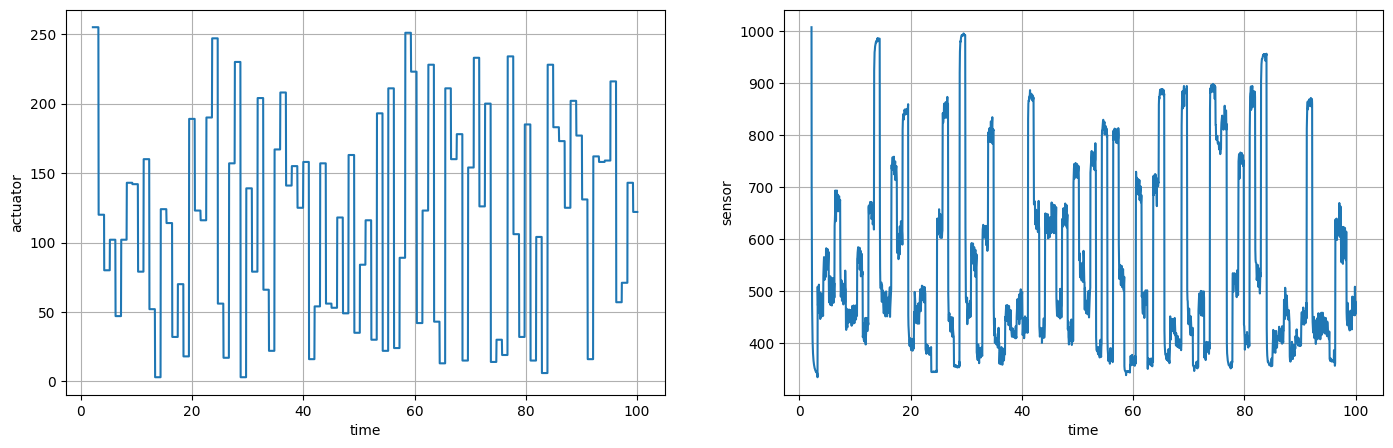

In [5]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, df.actuator)
plt.grid()
plt.xlabel('time'); plt.ylabel('actuator')

plt.subplot(1, 2, 2)
plt.plot(df.time, df.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel('sensor')

# PERÍODO DE AMOSTRAGEM
- Verificando a distribuição do período para verificar número de outliers

0.045


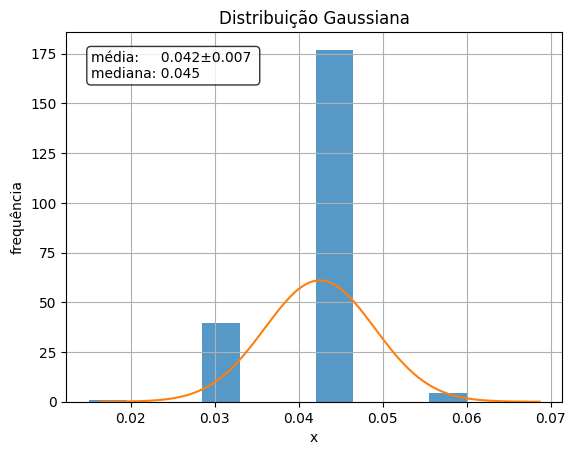

In [6]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(3)

print(dt)
gaussian(time)

In [7]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)

    target = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,actuator,sensor
0,0.000,255,1008
1,0.045,255,699
2,0.090,255,495
3,0.135,255,472
4,0.180,255,429
...,...,...,...
2172,97.740,122,509
2173,97.785,122,481
2174,97.830,122,467
2175,97.875,122,458


# VALORES PASSADOS

In [8]:
def getStates(df, key, var='y', n=10, last=True):
    table = df.copy() 
    table[f'{var}'] = table[key]

    for i in range(1, n):
        table[f'{var}(n-{i})'] = table[key].shift(i)

    table.fillna(0, inplace=True)
    columns = [f'{var}'] + [f'{var}(n-{i})' for i in range(1, n)]

    if not last:
        columns = columns[1:]

    return table[columns]


N_STATES = 5
xData    = pd.concat([
    getStates(df, 'actuator', var='u', n=N_STATES), 
    getStates(df, 'sensor', var='x', n=N_STATES, last=False)
], axis=1)

xData

,u,u(n-1),u(n-2),u(n-3),u(n-4),x(n-1),x(n-2),x(n-3),x(n-4)
0,255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,255,255.0,0.0,0.0,0.0,1008.0,0.0,0.0,0.0
2,255,255.0,255.0,0.0,0.0,699.0,1008.0,0.0,0.0
3,255,255.0,255.0,255.0,0.0,495.0,699.0,1008.0,0.0
4,255,255.0,255.0,255.0,255.0,472.0,495.0,699.0,1008.0
...,...,...,...,...,...,...,...,...,...
2172,122,122.0,122.0,122.0,122.0,454.0,462.0,466.0,478.0
2173,122,122.0,122.0,122.0,122.0,509.0,454.0,462.0,466.0
2174,122,122.0,122.0,122.0,122.0,481.0,509.0,454.0,462.0
2175,122,122.0,122.0,122.0,122.0,467.0,481.0,509.0,454.0


In [9]:
df = pd.concat([xData, df.sensor], axis=1)
df

,u,u(n-1),u(n-2),u(n-3),u(n-4),x(n-1),x(n-2),x(n-3),x(n-4),sensor
0,255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1008
1,255,255.0,0.0,0.0,0.0,1008.0,0.0,0.0,0.0,699
2,255,255.0,255.0,0.0,0.0,699.0,1008.0,0.0,0.0,495
3,255,255.0,255.0,255.0,0.0,495.0,699.0,1008.0,0.0,472
4,255,255.0,255.0,255.0,255.0,472.0,495.0,699.0,1008.0,429
...,...,...,...,...,...,...,...,...,...,...
2172,122,122.0,122.0,122.0,122.0,454.0,462.0,466.0,478.0,509
2173,122,122.0,122.0,122.0,122.0,509.0,454.0,462.0,466.0,481
2174,122,122.0,122.0,122.0,122.0,481.0,509.0,454.0,462.0,467
2175,122,122.0,122.0,122.0,122.0,467.0,481.0,509.0,454.0,458


In [10]:
df.to_csv('../Dataset/Model.csv', index=None)